In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import RegularGridInterpolator
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

from itertools import product
import matplotlib.colors as mcolors
from wrf_io import postproc

In [4]:
casenames = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/sweep_names.npy')
U_loc   = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/U_loc.npy')
dir_loc = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/dir_loc.npy')
U_disk   = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/U_disk.npy')
dir_disk = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/dir_disk.npy')
Uhub    = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/Uhub.npy')
wrf_tsr = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_tsr.npy')
wrf_omg = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_omg.npy')
Nelm    = np.load("/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/rotor_dims_10MW.npz")['Nelm']
Nsct    = np.load("/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/rotor_dims_10MW.npz")['Nsct']
rOverR  = np.load("/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/rotor_dims_10MW.npz")['rOverR']
R       = np.load("/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/rotor_dims_10MW.npz")['R']

In [5]:
indices = [14,15,16,17,18,19,20]

In [6]:
casenames[17]

np.str_('s00_v00')

In [7]:
veers = np.array([-0.15, -0.075, -0.025, 0, 0.025, 0.075, 0.15])

In [17]:
from MITRotor import BEM, BEMGeometry, IEA10MW, NoTipLoss, WRFLESAerodynamics, NoTangentialInduction, ConstantInduction

In [18]:
# LES Baseline

rotor = IEA10MW()

base_les_ind = np.zeros_like(indices, dtype='float')
base_les_cot = np.zeros_like(indices, dtype='float')
base_les_thr = np.zeros_like(indices, dtype='float')
base_les_cop = np.zeros_like(indices, dtype='float')
base_les_pow = np.zeros_like(indices, dtype='float')
iters   = np.zeros_like(indices, dtype='float')

for count in range(len(base_les_ind)):

    index = indices[count]

    bem = BEM(rotor=rotor, geometry=BEMGeometry(Nr=Nelm,Ntheta=Nsct,R=rotor.R, Rhub = rotor.hub_radius), aerodynamic_model=WRFLESAerodynamics(), tiploss_model=NoTipLoss(), momentum_model=ConstantInduction(a=0), tangential_induction_model=NoTangentialInduction())

    # sol = bem(0, wrf_tsr[index], 0, v_inf = Uhub[index], U = U_disk[:,:,index]/Uhub[index], wdir=dir_disk[:,:,index], veer = veers[count])
    sol = bem(0, 10.63, 0, v_inf = Uhub[index], U = U_disk[:,:,index]/Uhub[index], wdir=dir_disk[:,:,index], veer = veers[count])

    base_les_cot[count] = sol.Ct()
    base_les_thr[count] = sol.thrust()/1e3
    base_les_pow[count] = sol.power()/1e6
    base_les_cop[count] = sol.Cp()
    base_les_ind[count] = sol.a()
    iters[count]   = sol.niter

iters

array([7., 7., 7., 7., 7., 7., 7.])

In [ ]:
base_les_pow

array([2.91549066, 2.95806621, 2.96452119, 2.95743868, 2.93483345,
       2.8979176 , 2.7930898 ])

In [34]:
base_les_pow = np.array([
    3.4604,
    3.5088,
    3.5165,
    3.5088,
    3.4834,
    3.4418,
    3.3240
])

In [19]:
from MITRotor import BEM, BEMGeometry, IEA10MW, NoTipLoss, WRFLESAerodynamics, NoTangentialInduction, ClassicalMomentum

In [20]:
# 1D Momentum Baseline

rotor = IEA10MW()

base_1D_ind = np.zeros_like(indices, dtype='float')
base_1D_cot = np.zeros_like(indices, dtype='float')
base_1D_thr = np.zeros_like(indices, dtype='float')
base_1D_cop = np.zeros_like(indices, dtype='float')
base_1D_pow = np.zeros_like(indices, dtype='float')
iters       = np.zeros_like(indices, dtype='float')

for count in range(len(base_1D_ind)):

    index = indices[count]

    bem = BEM(rotor=rotor, geometry=BEMGeometry(Nr=Nelm,Ntheta=Nsct,R=rotor.R, Rhub = rotor.hub_radius), aerodynamic_model=WRFLESAerodynamics(), tiploss_model=NoTipLoss(), momentum_model=ClassicalMomentum(averaging='rotor'), tangential_induction_model=NoTangentialInduction())

    # sol = bem(0, wrf_tsr[index], 0, v_inf = Uhub[index], U = U_loc[:,:,index]/Uhub[index], wdir=dir_loc[:,:,index], veer = veers[count])
    sol = bem(np.deg2rad(0.0),10.634, 0, v_inf = 7, U = U_loc[:,:,index]/Uhub[index], wdir=dir_loc[:,:,index])

    base_1D_cot[count] = sol.Ct()
    base_1D_thr[count] = sol.thrust()/1e3
    base_1D_pow[count] = sol.power()/1e6
    base_1D_cop[count] = sol.Cp()
    base_1D_ind[count] = sol.a()
    iters[count]   = sol.niter

iters

array([ 9.,  9.,  9., 10., 10., 10., 10.])

In [22]:
base_1D_pow 

array([3.1612114 , 3.14000671, 3.12930585, 3.11866218, 3.10799681,
       3.0973384 , 3.0762243 ])

In [74]:
base_1D_pow = base_1D_pow * 0.944
base_1D_pow

array([2.98019049, 2.96541037, 2.95782415, 2.95022392, 2.94257595,
       2.93491235, 2.91967112])

In [75]:
from MITRotor import BEM, BEMGeometry, IEA10MW, NoTipLoss, WRFLESAerodynamics, NoTangentialInduction, MadsenMomentum

In [99]:
# Madsen Baseline

rotor = IEA10MW()

base_mad_ind = np.zeros_like(indices, dtype='float')
base_mad_cot = np.zeros_like(indices, dtype='float')
base_mad_thr = np.zeros_like(indices, dtype='float')
base_mad_cop = np.zeros_like(indices, dtype='float')
base_mad_pow = np.zeros_like(indices, dtype='float')
iters        = np.zeros_like(indices, dtype='float')

for count in range(len(base_mad_ind)):

    index = indices[count]

    bem = BEM(rotor=rotor, geometry=BEMGeometry(Nr=Nelm,Ntheta=Nsct,R=rotor.R, Rhub = rotor.hub_radius), aerodynamic_model=WRFLESAerodynamics(), tiploss_model=NoTipLoss(), momentum_model=MadsenMomentum(averaging='rotor'), tangential_induction_model=NoTangentialInduction())

    sol = bem(np.deg2rad(0.0),9.4, 0, v_inf = Uhub[index], U = U_loc[:,:,index]/Uhub[index], wdir=dir_loc[:,:,index], veer = veers[count])

    base_mad_cot[count] = sol.Ct()
    base_mad_thr[count] = sol.thrust()/1e3
    base_mad_pow[count] = sol.power()/1e6
    base_mad_cop[count] = sol.Cp()
    base_mad_ind[count] = sol.a()
    iters[count]   = sol.niter
    
iters

array([5., 5., 5., 5., 5., 5., 5.])

In [95]:
base_mad_pow

array([3.08613357, 3.07170769, 3.06440302, 3.05709277, 3.04979213,
       3.04250198, 3.027945  ])

In [100]:
base_mad_pow * 0.944

array([2.98927169, 2.97429062, 2.9667255 , 2.95916584, 2.95158846,
       2.94401986, 2.92905065])

In [102]:
base_mad_pow =  base_mad_pow * 0.944

In [8]:
from MITRotor import BEM, BEMGeometry, IEA10MW, NoTipLoss, WRFLESAerodynamics, NoTangentialInduction, ConstantInduction_GP

In [33]:
rotor = IEA10MW()

gpr_ind = np.zeros_like(indices, dtype='float')
gpr_cot = np.zeros_like(indices, dtype='float')
gpr_thr = np.zeros_like(indices, dtype='float')
gpr_cop = np.zeros_like(indices, dtype='float')
gpr_pow = np.zeros_like(indices, dtype='float')
iters   = np.zeros_like(indices, dtype='float')

for count in range(len(gpr_ind)):
# for count in [17]:

# for count in [4]:

    index = indices[count]
    # index = 17
    # count=3
    bem = BEM(rotor=rotor, geometry=BEMGeometry(Nr=Nelm,Ntheta=Nsct,R=rotor.R, Rhub = rotor.hub_radius), aerodynamic_model=WRFLESAerodynamics(), tiploss_model=NoTipLoss(), momentum_model=ConstantInduction_GP(veer = veers[count]), tangential_induction_model=NoTangentialInduction())

    sol = bem(np.deg2rad(0.0),10.634, 0, v_inf = Uhub[index], U = U_loc[:,:,index]/Uhub[index], wdir=dir_loc[:,:,index], veer = veers[count])

    gpr_cot[count] = sol.Ct()
    gpr_thr[count] = sol.thrust()/1e3
    gpr_pow[count] = sol.power()/1e6
    gpr_cop[count] = sol.Cp()
    gpr_ind[count] = sol.a()
    iters[count]   = sol.niter
    
iters

array([5., 5., 5., 5., 5., 5., 5.])

In [22]:
gpr_cot

array([0.92874975, 0.93241682, 0.93359038, 0.93570079, 0.93785085,
       0.9389919 , 0.94263457])

In [39]:
gpr_ind

array([0.30437153, 0.30337147, 0.30397141, 0.30407491, 0.30457673,
       0.30773554, 0.31365263])

In [31]:
gpr_pow

array([2.99248209, 2.98281422, 2.97098597, 2.96823671, 2.96497231,
       2.94271039, 2.90731961])

In [109]:
gpr_pow * 0.944

array([2.82490309, 2.81577662, 2.80461076, 2.80201545, 2.79893386,
       2.77791861, 2.74450971])

In [118]:
gpr_pow = gpr_pow * 0.944

In [90]:
gpr_cot

array([0.85713003, 0.86466579, 0.86729293, 0.86983991, 0.87195999,
       0.87121484, 0.86877831])

In [24]:
from MITRotor import BEM, BEMGeometry, IEA10MW, NoTipLoss, WRFLESAerodynamics, NoTangentialInduction, GP_Annulus

In [27]:
rotor = IEA10MW()

gpa_ind = np.zeros_like(indices, dtype='float')
gpa_cot = np.zeros_like(indices, dtype='float')
gpa_thr = np.zeros_like(indices, dtype='float')
gpa_cop = np.zeros_like(indices, dtype='float')
gpa_pow = np.zeros_like(indices, dtype='float')
iters   = np.zeros_like(indices, dtype='float')

gpa_ind_a = np.zeros((Nelm,len(indices)), dtype='float')
gpa_cot_a = np.zeros((Nelm,len(indices)), dtype='float')

for count in range(len(gpa_ind)):
# for count in [4]:

    index = indices[count]

    bem = BEM(rotor=rotor, geometry=BEMGeometry(Nr=Nelm,Ntheta=Nsct,R=rotor.R, Rhub = rotor.hub_radius), aerodynamic_model=WRFLESAerodynamics(), tiploss_model=NoTipLoss(), momentum_model=GP_Annulus(veer=veers[count]), tangential_induction_model=NoTangentialInduction())

    sol = bem(0, 9.59, 0, v_inf = Uhub[index], U = U_loc[:,:,index]/Uhub[index], wdir=dir_loc[:,:,index], veer = veers[count])

    gpa_cot[count] = sol.Ct()
    gpa_thr[count] = sol.thrust()/1e3
    gpa_pow[count] = sol.power()/1e6
    gpa_cop[count] = sol.Cp()
    gpa_ind[count] = sol.a()
    iters[count]   = sol.niter

    gpa_ind_a[:,count] = sol.a('annulus')
    gpa_cot_a[:,count] = sol.Ct('annulus')

iters

AttributeError: 'numpy.ndarray' object has no attribute 'C_x'

In [168]:
gpa_pow

array([3.09172113, 3.11815444, 3.11848963, 3.11329227, 3.12188274,
       3.09823773, 3.08815397, 3.05647136, 2.96507554])

In [15]:
np.load('/scratch/09909/smata/induction_modeling/gaussian_process/10MW/train_data/wrf_ind_ann.npy')

array([[0.02505624, 0.02160859, 0.02177606, ..., 0.02229271, 0.02634228,
        0.03899398],
       [0.01138334, 0.00788872, 0.00806968, ..., 0.00669677, 0.01079605,
        0.02365014],
       [0.03726974, 0.03440164, 0.03510936, ..., 0.04214369, 0.04803543,
        0.06525613],
       ...,
       [0.1349138 , 0.12762911, 0.12624779, ..., 0.12596514, 0.12969847,
        0.142928  ],
       [0.09527242, 0.08740569, 0.08576784, ..., 0.0845747 , 0.08810629,
        0.101028  ],
       [0.05346516, 0.04488632, 0.04294824, ..., 0.04022299, 0.04352194,
        0.05612402]], shape=(26, 63), dtype=float128)

In [ ]:
num_calls = 8
save_dir = '/scratch/09909/smata/temp_4'

all_Ct = [np.load(f'{save_dir}/Ct_{i:04d}.npy') for i in range(num_calls)]
all_a  = [np.load(f'{save_dir}/a_{i:04d}.npy')  for i in range(num_calls)]

In [ ]:
all_a

[array([0.03349127, 0.01772814, 0.0516741 , 0.1510551 , 0.2480352 ,
        0.30521577, 0.33127682, 0.33569528, 0.33483733, 0.33191461,
        0.32505394, 0.32343303, 0.32746961, 0.32821997, 0.32500481,
        0.32460246, 0.32682473, 0.3229814 , 0.30687435, 0.28042356,
        0.24898454, 0.21468291, 0.17743089, 0.13890931, 0.09716235,
        0.0544846 ]),
 array([0.03349127, 0.01772814, 0.0516741 , 0.1510551 , 0.2480352 ,
        0.30521577, 0.33127682, 0.33569528, 0.33483733, 0.33191461,
        0.32505394, 0.32343303, 0.32746961, 0.32821997, 0.32500481,
        0.32460246, 0.32682473, 0.3229814 , 0.30687435, 0.28042356,
        0.24898454, 0.21468291, 0.17743089, 0.13890931, 0.09716235,
        0.0544846 ]),
 array([0.03349127, 0.01772814, 0.0516741 , 0.1510551 , 0.2480352 ,
        0.30521577, 0.33127682, 0.33569528, 0.33483733, 0.33191461,
        0.32505394, 0.32343303, 0.32746961, 0.32821997, 0.32500481,
        0.32460246, 0.32682473, 0.3229814 , 0.30687435, 0.28042356,
    

Text(0.5, 0, '$a$ [-]')

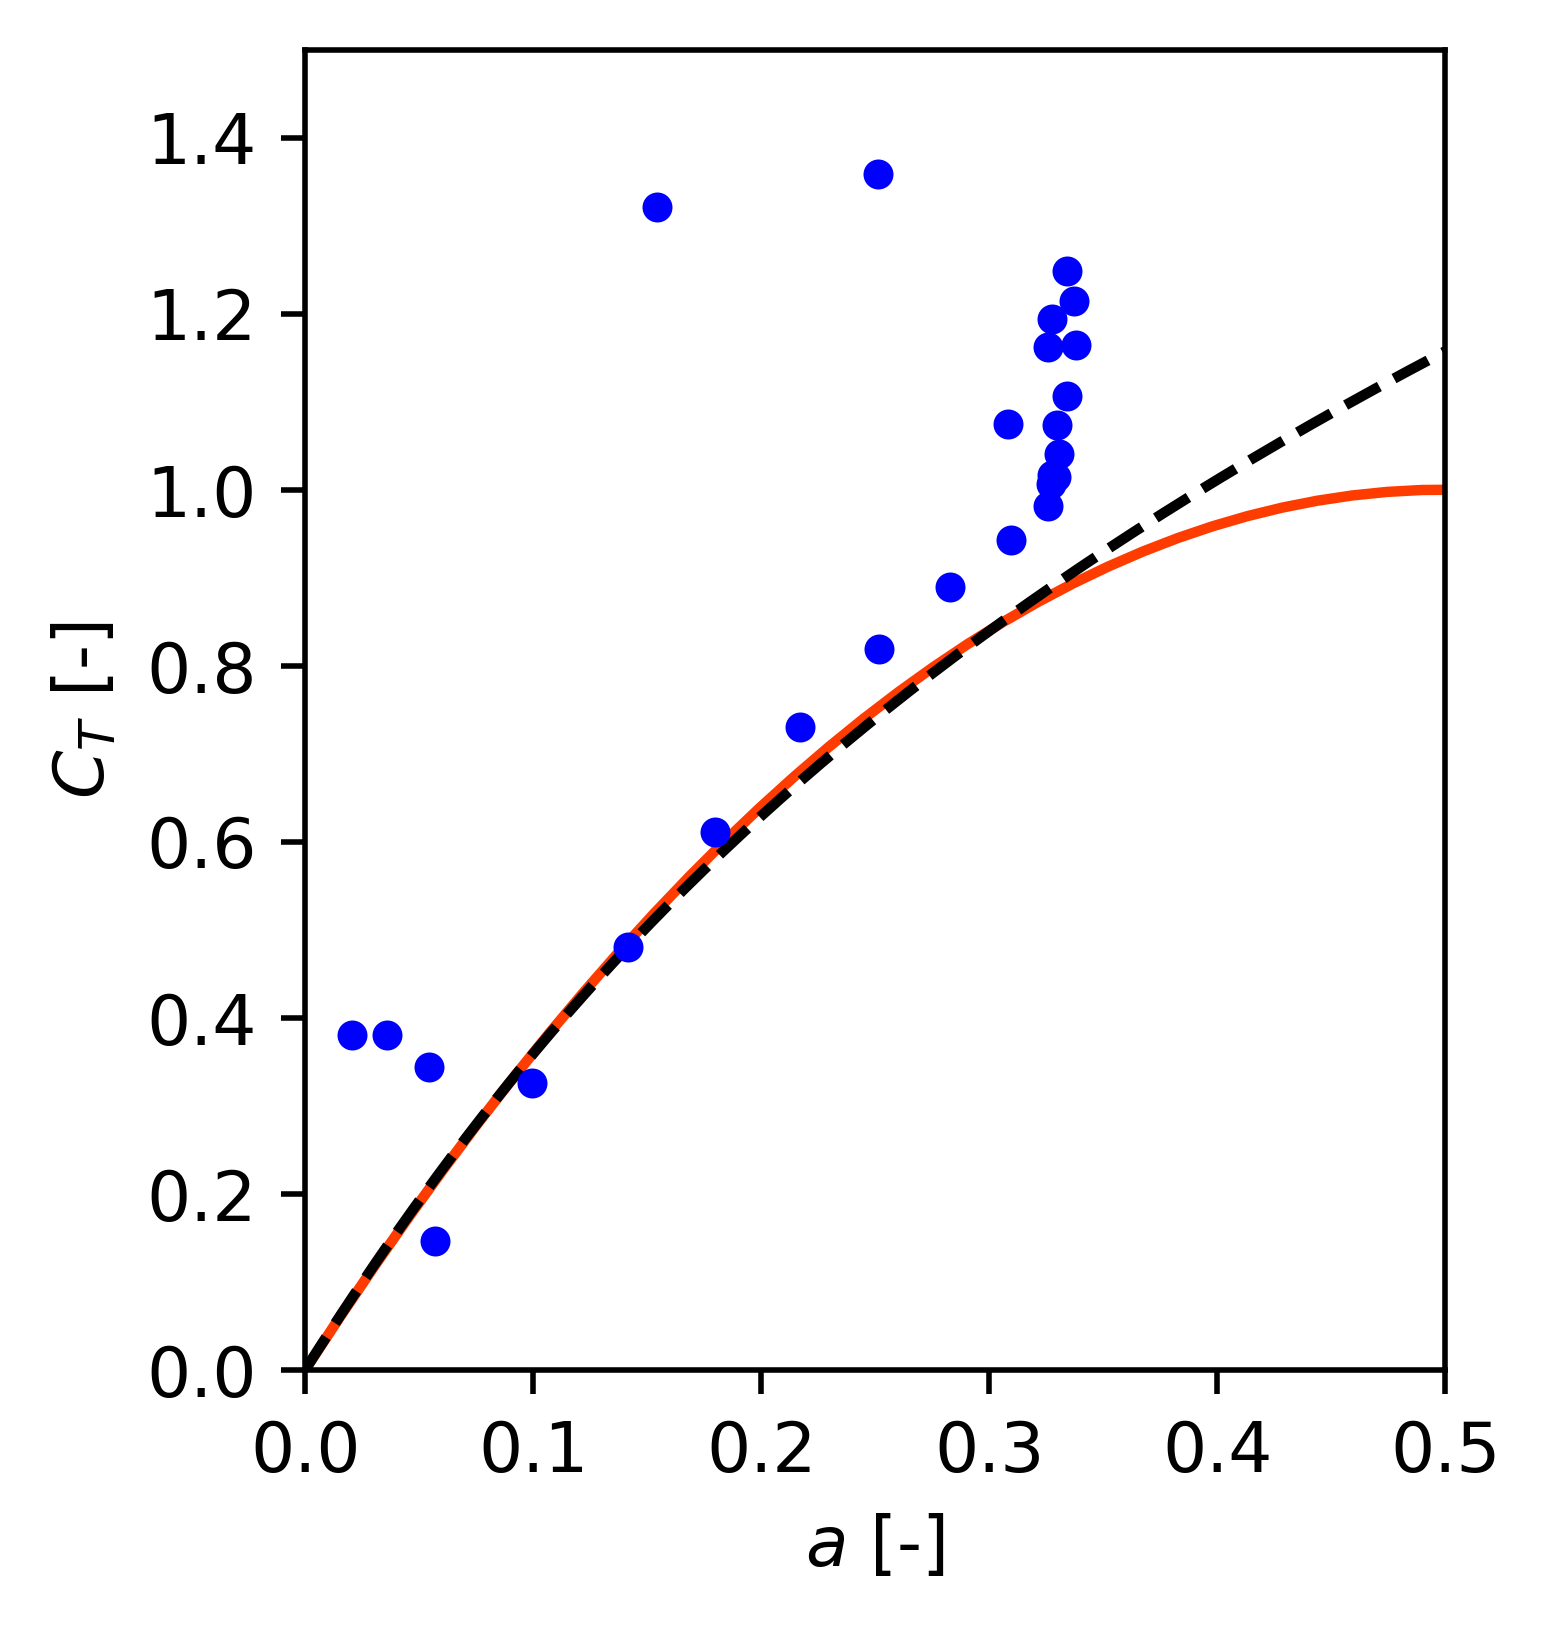

In [187]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import pandas as pd

# === Reference curves ===
a_mom = np.linspace(0, 0.75, 50)
ct_mom = 4 * a_mom * (1 - a_mom)

a_vals = gpa_ind_a[:,4]
ct_vals = gpa_cot_a[:,4]

# a_vals = gpa_ind
# ct_vals = gpa_cot

ct_mad = np.linspace(0, 1.5, 75)
k1, k2, k3 = 0.2460, 0.0586, 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad

# === Setup figure ===
fig, ax = plt.subplots(figsize=(3, 3))
fig.subplots_adjust(left=0.22, right=0.98, top=0.98, bottom=0.1)  # Adjust as needed

ax.plot(a_mom, ct_mom, '#ff3c00', zorder=1, label='Classical Momentum')
ax.plot(a_mad, ct_mad, 'k--', zorder=1, label='Madsen Model')
scatter_plot, = ax.plot([], [], 'ro', markersize=1, label='GP prediction')
ax.scatter(a_vals, ct_vals,11,color='b',label='Training data')

# # ax.set_xlim([0, 0.5])
# # ax.set_ylim([0.625, 0.8])
ax.set_xlim([0,0.5])
ax.set_ylim([0,1.5])
ax.set_ylabel('$C_T$ [-]')
ax.set_xlabel('$a$ [-]')
# # ax.legend(loc='lower right', fontsize=6)

# # === Animation update function ===
# # def update(frame):
# #     scatter_plot.set_data(all_a[:frame+1], all_Ct[:frame+1])
# #     return scatter_plot,

# # === Create dynamic text elements ===
# iteration_text = ax.text(0.02, 0.98, '', transform=ax.transAxes,
#                          ha='left', va='top', fontsize=8)
# rmse_text = ax.text(0.02, 0.935, '', transform=ax.transAxes,
#                     ha='left', va='top', fontsize=8)

# # === RMSE helper ===
# def rmse(y_pred, y_true):
#     return np.sqrt(np.mean((y_pred - y_true)**2))

# # === Animation update function ===
# def update(frame):
#     a_pred = all_a[frame]
#     ct_pred = all_Ct[frame]

#     scatter_plot.set_data(a_pred, ct_pred)

#     rmse_a = rmse(a_pred, a_vals)
#     rmse_ct = rmse(ct_pred, ct_vals)

#     iteration_text.set_text(f'Iteration: {frame}')
#     rmse_text.set_text(f'RMSE: a={rmse_a:.4f}, Ct={rmse_ct:.4f}')
#     return scatter_plot, iteration_text, rmse_text

# ani = FuncAnimation(fig, update, frames=len(all_a), interval=200, blit=True)

# # === Save to MP4 ===
# # ani.save("/home1/09909/smata/dir_scratch/ann_search_n025.gif", writer='pillow', fps=3, dpi=300)
# ani.save("/home1/09909/smata/dir_scratch/ann_search_000.gif", writer='pillow', fps=3, dpi=300)

[Text(0, 0, '-0.2'),
 Text(1, 0, '-0.1'),
 Text(2, 0, '-0.05'),
 Text(3, 0, '0'),
 Text(4, 0, '0.05'),
 Text(5, 0, '0.1'),
 Text(6, 0, '0.2')]

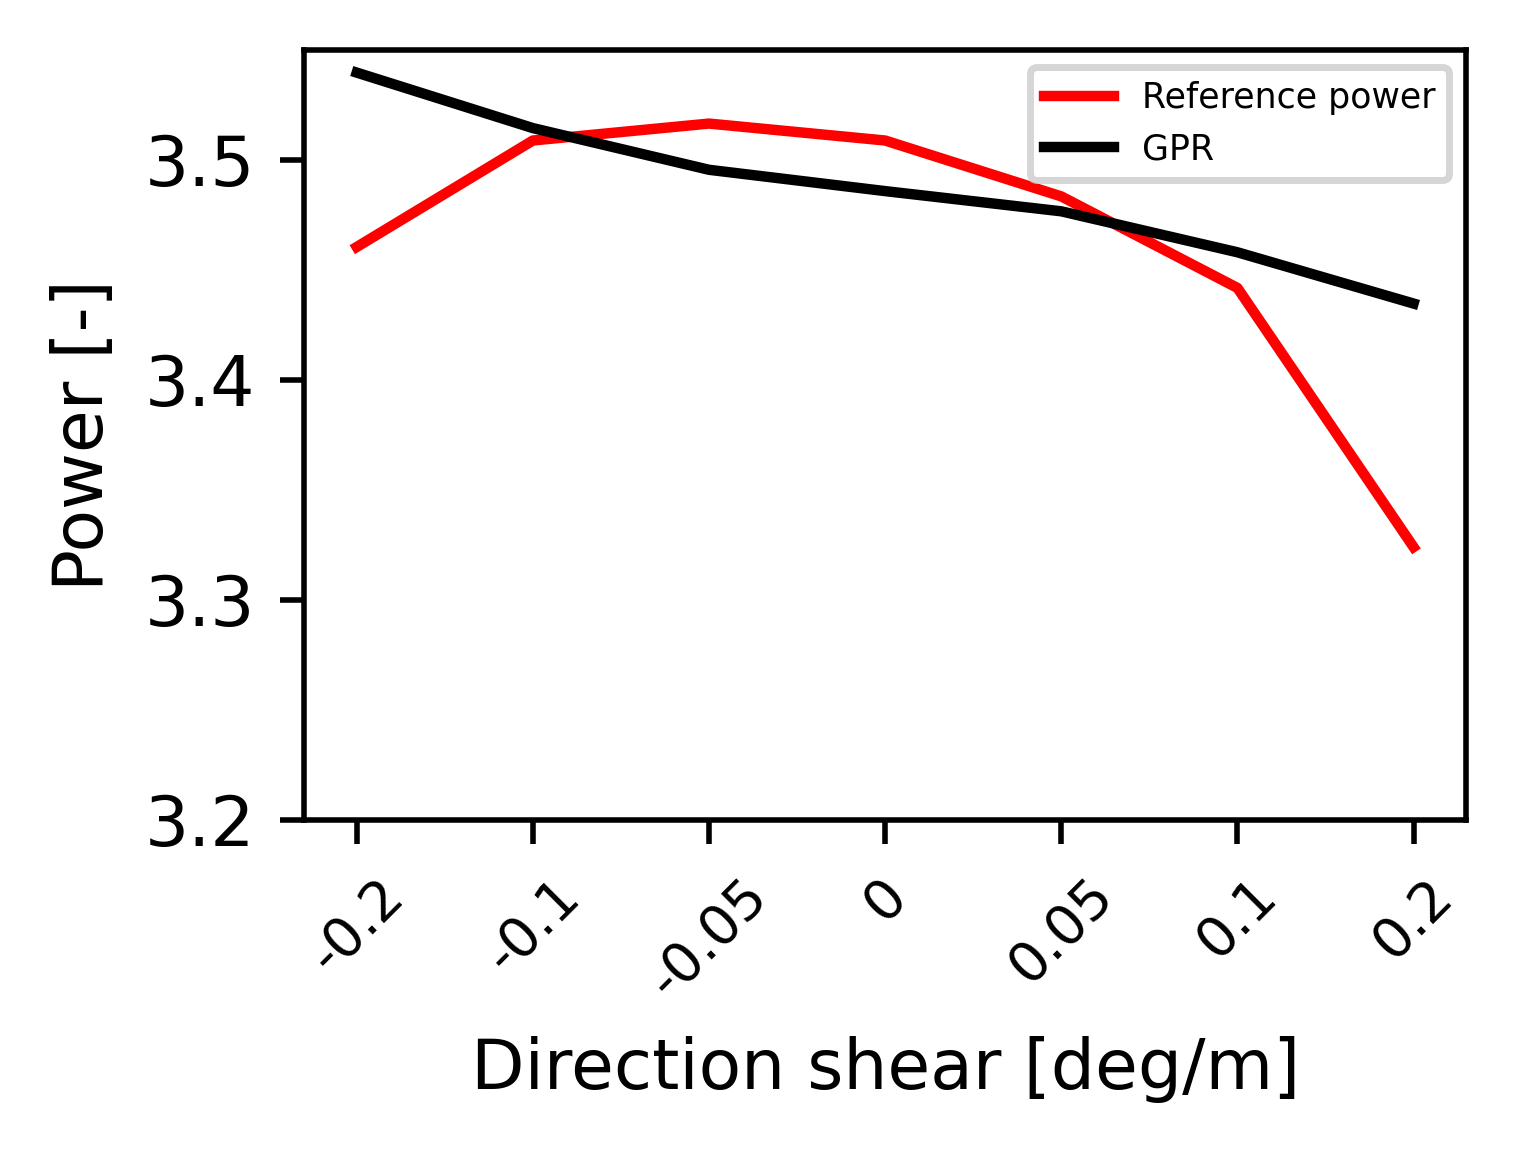

In [36]:
# ROTOR AVERAGE
fig, ax = plt.subplots(figsize=(3, 2))

rated = 1

ax.plot(base_les_pow/rated, color='r', label='Reference power')
# ax.plot(base_1D_pow/rated, color='g', label='1D mom. theory')
# ax.plot(base_mad_pow/rated, color='b', label='Madsen')
ax.plot(gpr_pow/rated , color='k', label='GPR')
ax.legend(fontsize=5)

ax.set_ylabel('Power [-]')
ax.set_xlabel('Direction shear [deg/m]')

ax.set_ylim([3.2,3.55])

# ax.set_yscale('log')

tick_positions = [0,1,2,3,4,5,6]  # indices along the x-axis
tick_labels = ['-0.2', '-0.1', '-0.05', '0', '0.05', '0.1', '0.2']
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, fontsize=8)

[Text(0, 0, '-0.2'),
 Text(1, 0, '-0.1'),
 Text(2, 0, '-0.05'),
 Text(3, 0, '-0.025'),
 Text(4, 0, '0'),
 Text(5, 0, '0.025'),
 Text(6, 0, '0.05'),
 Text(7, 0, '0.1'),
 Text(8, 0, '0.2')]

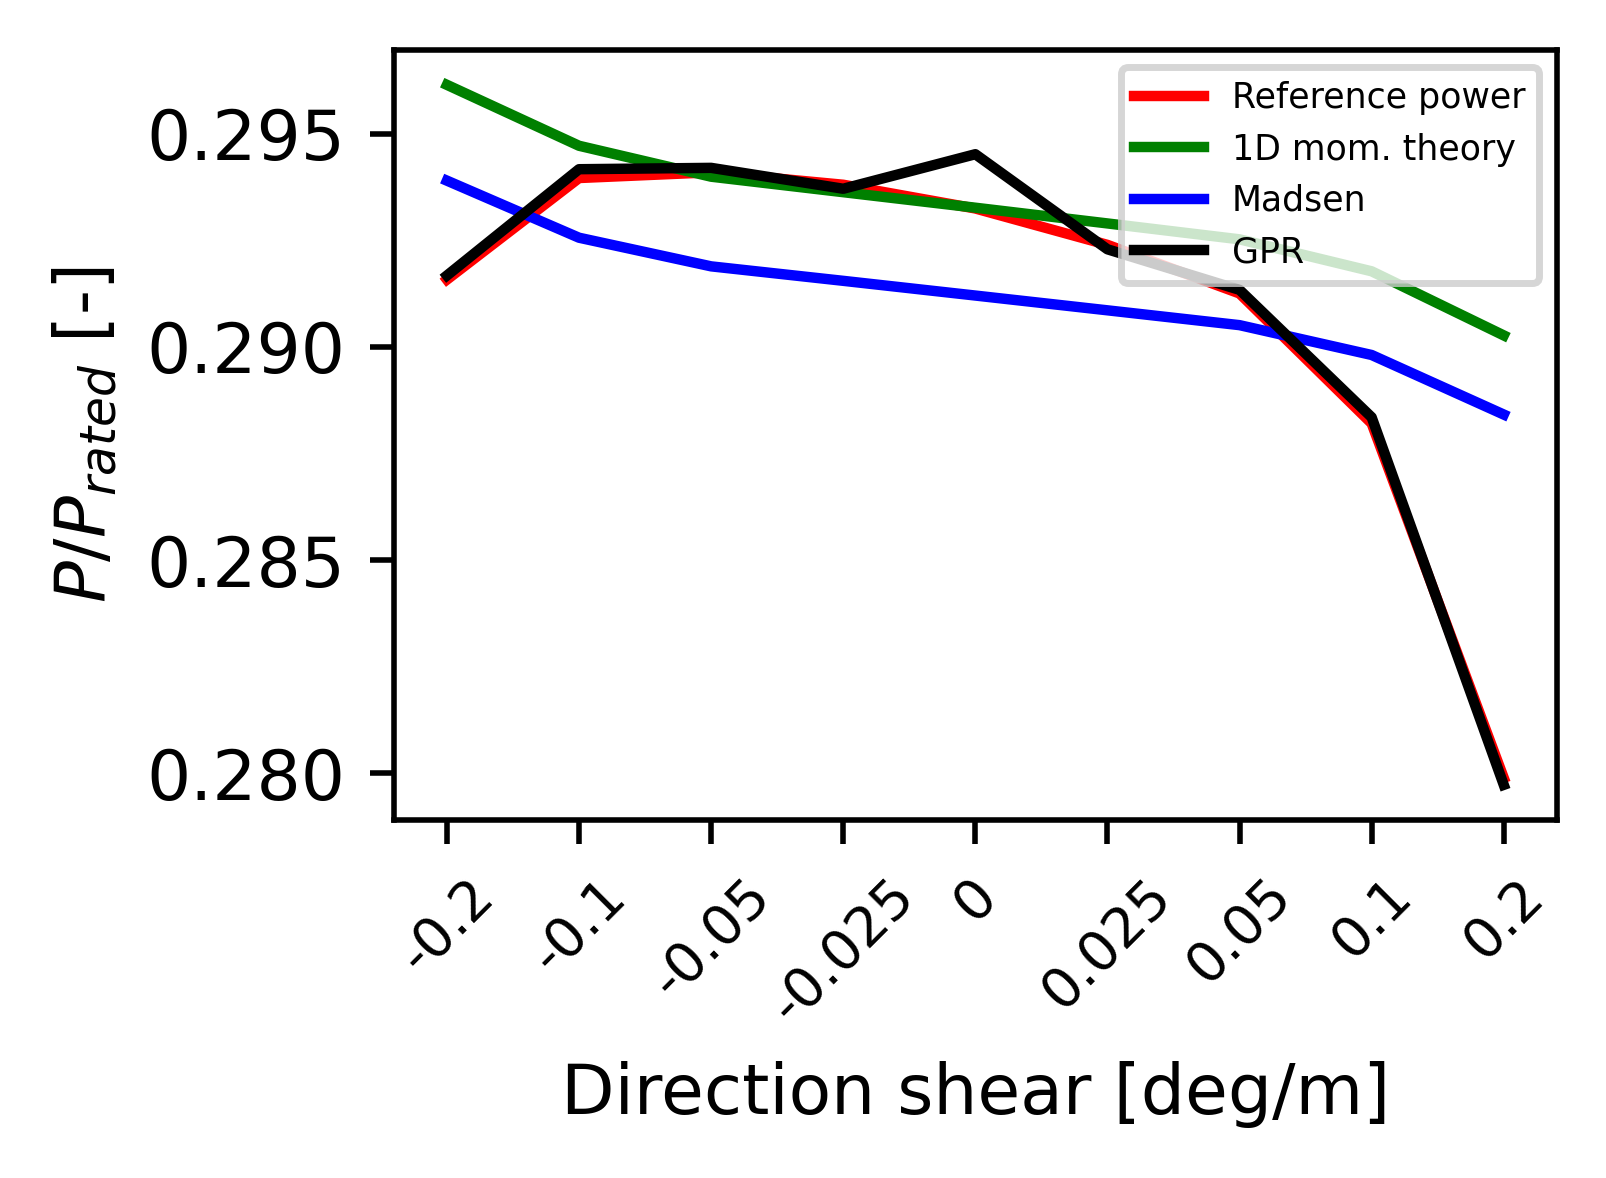

In [182]:
# ANNULUS AVERAGE
fig, ax = plt.subplots(figsize=(3, 2))

ax.plot(base_les_pow/rated, color='r', label='Reference power')
ax.plot(base_1D_pow/rated, color='g', label='1D mom. theory')
ax.plot(base_mad_pow/rated, color='b', label='Madsen')
ax.plot(gpa_pow/rated, color='k', label='GPR')
ax.legend(fontsize=5, loc='upper right')

ax.set_ylabel('$P/P_{rated}$ [-]')
ax.set_xlabel('Direction shear [deg/m]')

# ax.set_yscale('log')

# ax.set_ylim([2.75,4.4])

tick_positions = [0,1,2,3,4,5,6,7,8]  # indices along the x-axis
tick_labels = ['-0.2', '-0.1', '-0.05', '-0.025', '0', '0.025', '0.05', '0.1', '0.2']
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, fontsize=8)

[Text(0, 0, '-0.2'),
 Text(1, 0, '-0.1'),
 Text(2, 0, '-0.05'),
 Text(3, 0, '-0.025'),
 Text(4, 0, '0'),
 Text(5, 0, '0.025'),
 Text(6, 0, '0.05'),
 Text(7, 0, '0.1'),
 Text(8, 0, '0.2')]

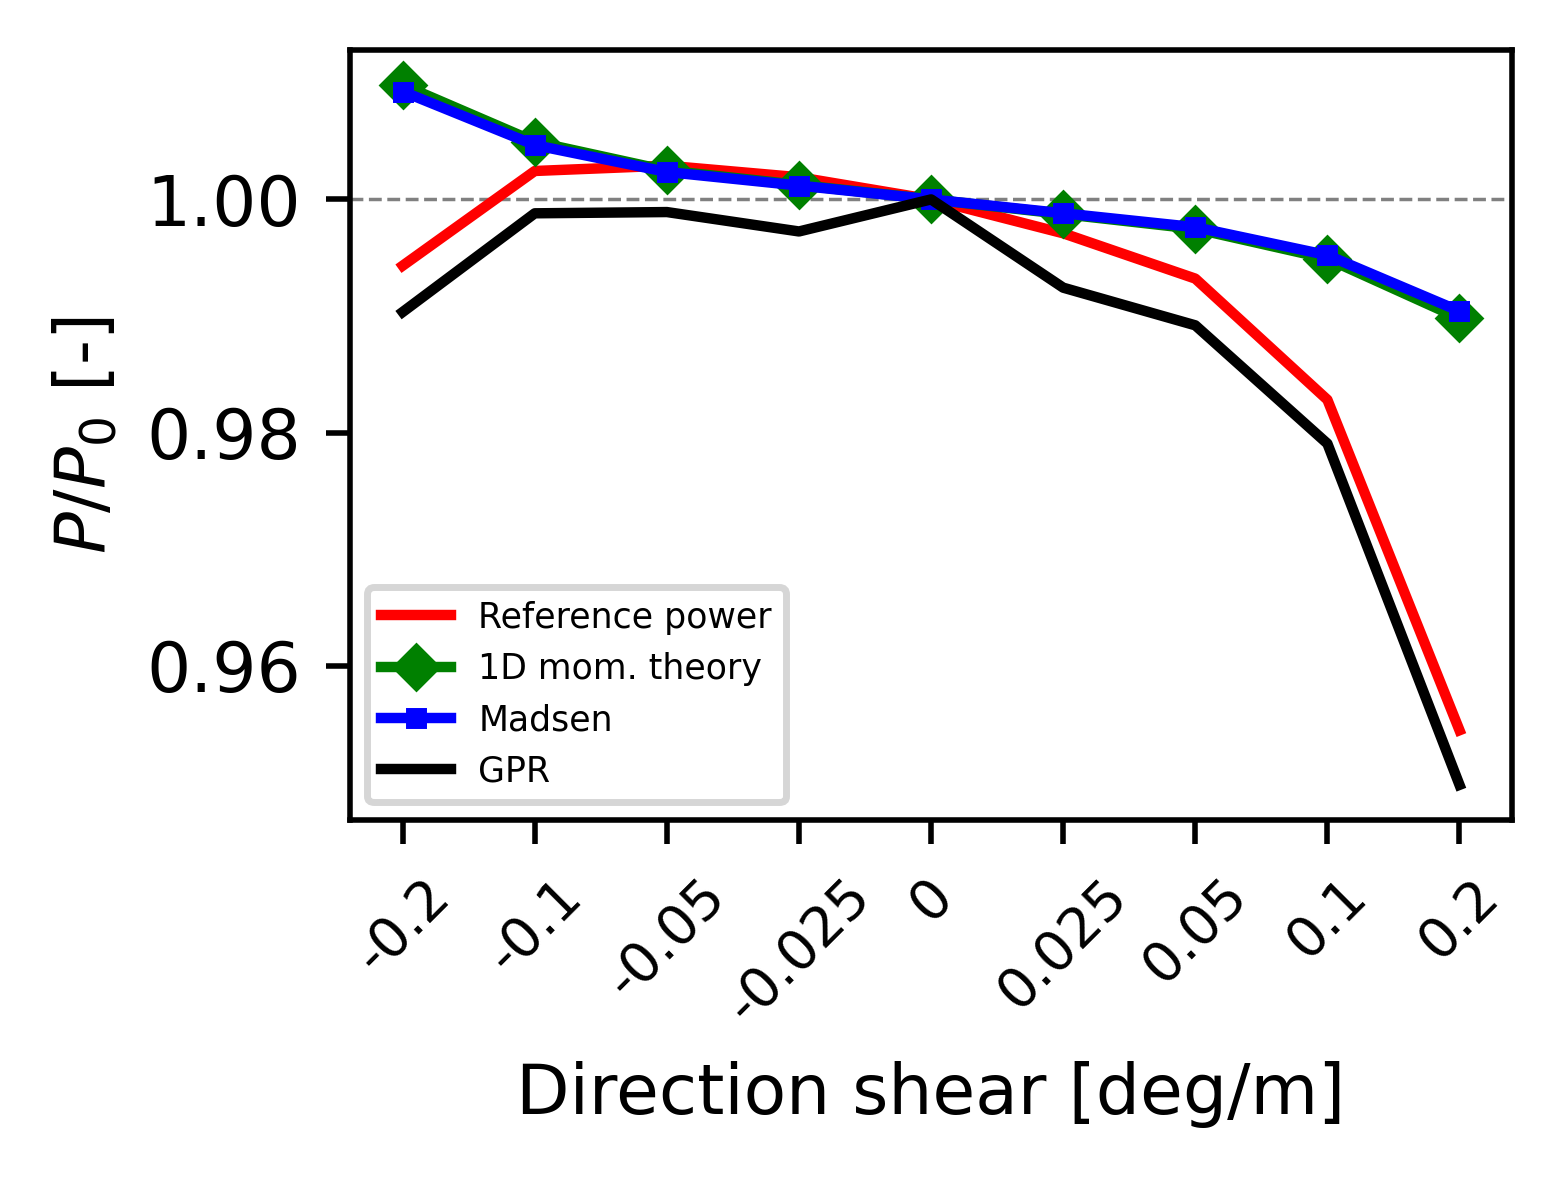

In [170]:
fig, ax = plt.subplots(figsize=(3, 2))

ref_ind = 4

ax.plot(base_les_pow/base_les_pow[ref_ind], color='r', label='Reference power')
ax.plot(base_1D_pow/base_1D_pow[ref_ind], marker='D', markersize=4,color='g', label='1D mom. theory')
ax.plot(base_mad_pow/base_mad_pow[ref_ind], marker = 's', markersize=2, color='b', label='Madsen')
ax.plot(gpa_pow/gpa_pow[ref_ind], color='k', label='GPR')

ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.5,zorder=1)

ax.legend(fontsize=5)

ax.set_ylabel('$P/P_0$ [-]')
ax.set_xlabel('Direction shear [deg/m]')

tick_positions = [0,1,2,3,4,5,6,7,8]  # indices along the x-axis
tick_labels = ['-0.2', '-0.1', '-0.05', '-0.025', '0', '0.025', '0.05', '0.1', '0.2']
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, fontsize=8)

# ax.set_yscale('log')

In [28]:
(gpa_pow/gpa_pow[ref_ind]-1)*100

array([-0.65292279,  0.2185483 ,  0.24163665,  0.08086076,  0.        ,
       -0.39153415, -0.70979836, -1.7221041 , -4.67194242])

In [29]:
postproc.per_error(gpa_pow,base_les_pow[4])

array([-0.50987934,  0.36284652,  0.38596812,  0.22496074,  0.14398355,
       -0.24811435, -0.5668368 , -1.58060009, -4.5346857 ])

In [ ]:
# Load training data
from scipy.io import loadmat
base_path = '/home1/09909/smata/dir_scratch/induction_modeling/gaussian_process/10MW'
X_train_rot = loadmat(base_path + '/train_data/wrf_10MW_ann.mat')

X_rot = X_train_rot['X']
y_rot = X_train_rot['y'].ravel()

# Load test data
X_test_rot = loadmat(base_path + '/test_data/wrf_10MW_ann.mat')
import pickle

# Replace with the actual file path
with open(base_path + '/train_data/scaler_wrf_cot_ann.pkl', 'rb') as f:
    obj_cot1 = pickle.load(f)

with open(base_path + '/train_data/scaler_shears_ann.pkl', 'rb') as f:
    obj_cot2 = pickle.load(f)

with open(base_path + '/train_data/scaler_veers_ann.pkl', 'rb') as f:
    obj_cot3 = pickle.load(f)

with open(base_path + '/train_data/scaler_wrf_ind_ann.pkl', 'rb') as f:
    obj_ann = pickle.load(f)

X_rot[:,1] = obj_cot1.inverse_transform(X_rot[:,1].reshape(-1, 1)).ravel()
X_rot[:,2] = obj_cot2.inverse_transform(X_rot[:,2].reshape(-1, 1)).ravel()
X_rot[:,3] = obj_cot3.inverse_transform(X_rot[:,3].reshape(-1, 1)).ravel()
y_rot = obj_ann.inverse_transform(y_rot.reshape(-1, 1)).ravel()

X_rot[:,2] = np.round(X_rot[:,2], 3)
X_rot[:,3] = np.round(X_rot[:,3], 3)

uniform = [i for i, (r, ct, s, v) in enumerate(X_rot) if (abs(v) < 0.01 and abs(s) < 0.01)]
# uniform = [i for i, (r, ct, s, v) in enumerate(X_rot) if (v == 0.025 and abs(s) < 0.01)]

In [ ]:
X_rot[0:50,3]

array([-0.2  , -0.1  , -0.05 , -0.025,  0.   ,  0.025,  0.05 ,  0.1  ,
        0.2  , -0.2  , -0.1  , -0.05 , -0.025,  0.   ,  0.025,  0.05 ,
        0.1  ,  0.2  , -0.2  , -0.1  , -0.05 , -0.025,  0.   ,  0.025,
        0.05 ,  0.1  ,  0.2  , -0.2  , -0.1  , -0.05 , -0.025,  0.   ,
        0.025,  0.05 ,  0.1  ,  0.2  , -0.2  , -0.1  , -0.05 , -0.025,
        0.   ,  0.025,  0.05 ,  0.1  ,  0.2  , -0.2  , -0.1  , -0.05 ,
       -0.025,  0.   ])

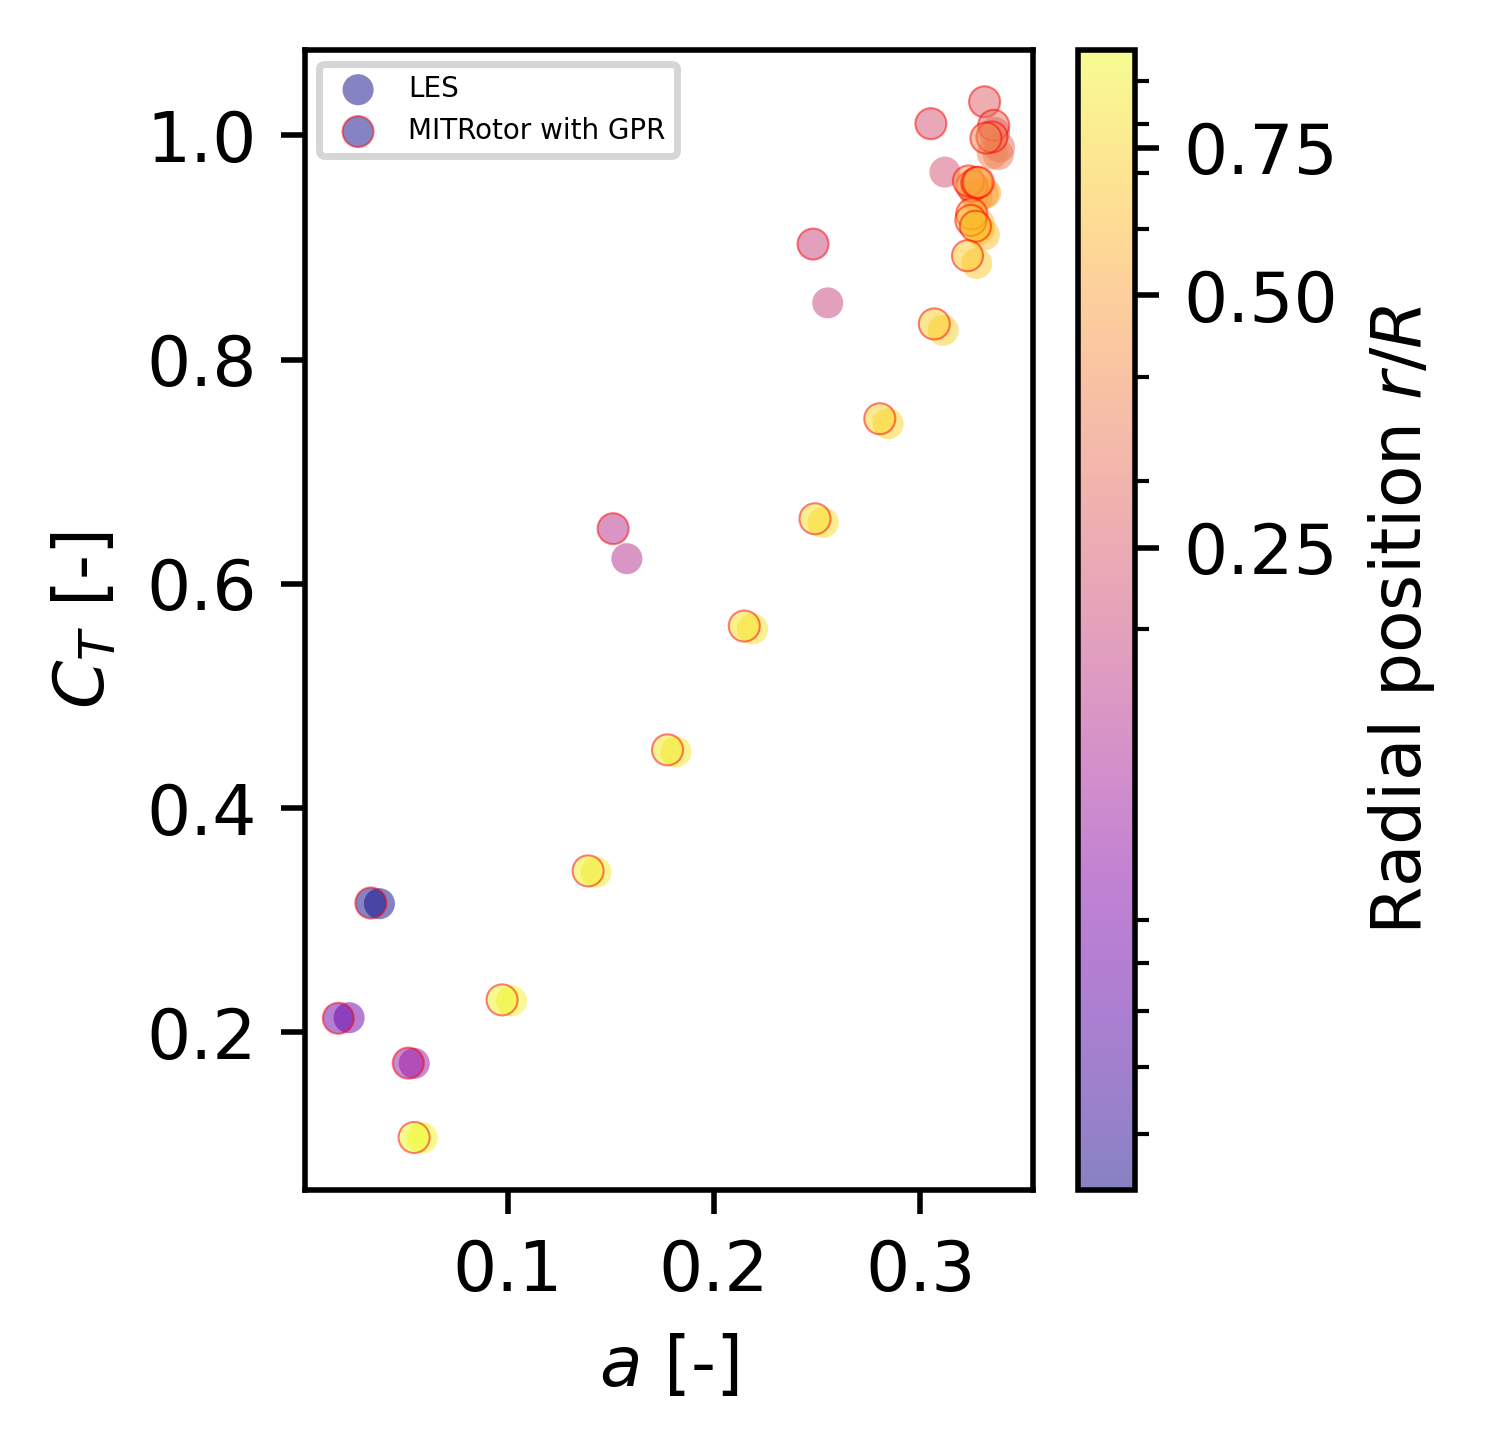

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# Select uniform inflow cases (low shear & veer)
# uniform = [i for i, (r, ct, s, v) in enumerate(X_rot) if (abs(v) < 0.01 and abs(s) < 0.01)]

# Extract values
r_vals = X_rot[uniform, 0]
a_vals = y_rot[uniform]
ct_vals = X_rot[uniform, 1]

# Create the scatter plot using actual r_vals for color
fig, ax = plt.subplots(figsize=(3, 3))
# sc = ax.scatter(a_vals, ct_vals, s=10, c=r_vals, cmap='viridis', marker='s', edgecolor='none', alpha=1.0)

import matplotlib.colors as mcolors

norm = mcolors.LogNorm(vmin=r_vals.min(), vmax=r_vals.max())

sc = ax.scatter(a_vals, ct_vals, s=20, c=r_vals, cmap='plasma',
                norm=norm, marker='o', edgecolor='none', linewidth=0.3, alpha=0.5, label='LES')

sc = ax.scatter(gpa_ind_a[:,4], gpa_cot_a[:,4], s=20, c=r_vals, cmap='plasma',
                norm=norm, marker='o', edgecolor='r', linewidth=0.3, alpha=0.5, label='MITRotor with GPR')

# cbar = plt.colorbar(sc, ax=ax)
cbar = plt.colorbar(sc, ax=ax, ticks=[0.25, 0.5, 0.75])
cbar.set_ticklabels(['0.25', '0.50', '0.75'])  # Optional: format to 2 decimals
cbar.set_label("Radial position $r/R$")

ax.set_ylabel('$C_T$ [-]')
ax.set_xlabel('$a$ [-]')
ax.legend(fontsize=4)
# ax.set_ylim([0.672,0.6952])

# Add colorbar that reflects radial position r
# cbar = plt.colorbar(sc, ax=ax, pad=0.02)
# cbar.set_label('Radial position $r/R$', fontsize=10)
# cbar.ax.tick_params(labelsize=8)



plt.tight_layout()
plt.show()


Text(0.5, 0, '$a$ [-]')

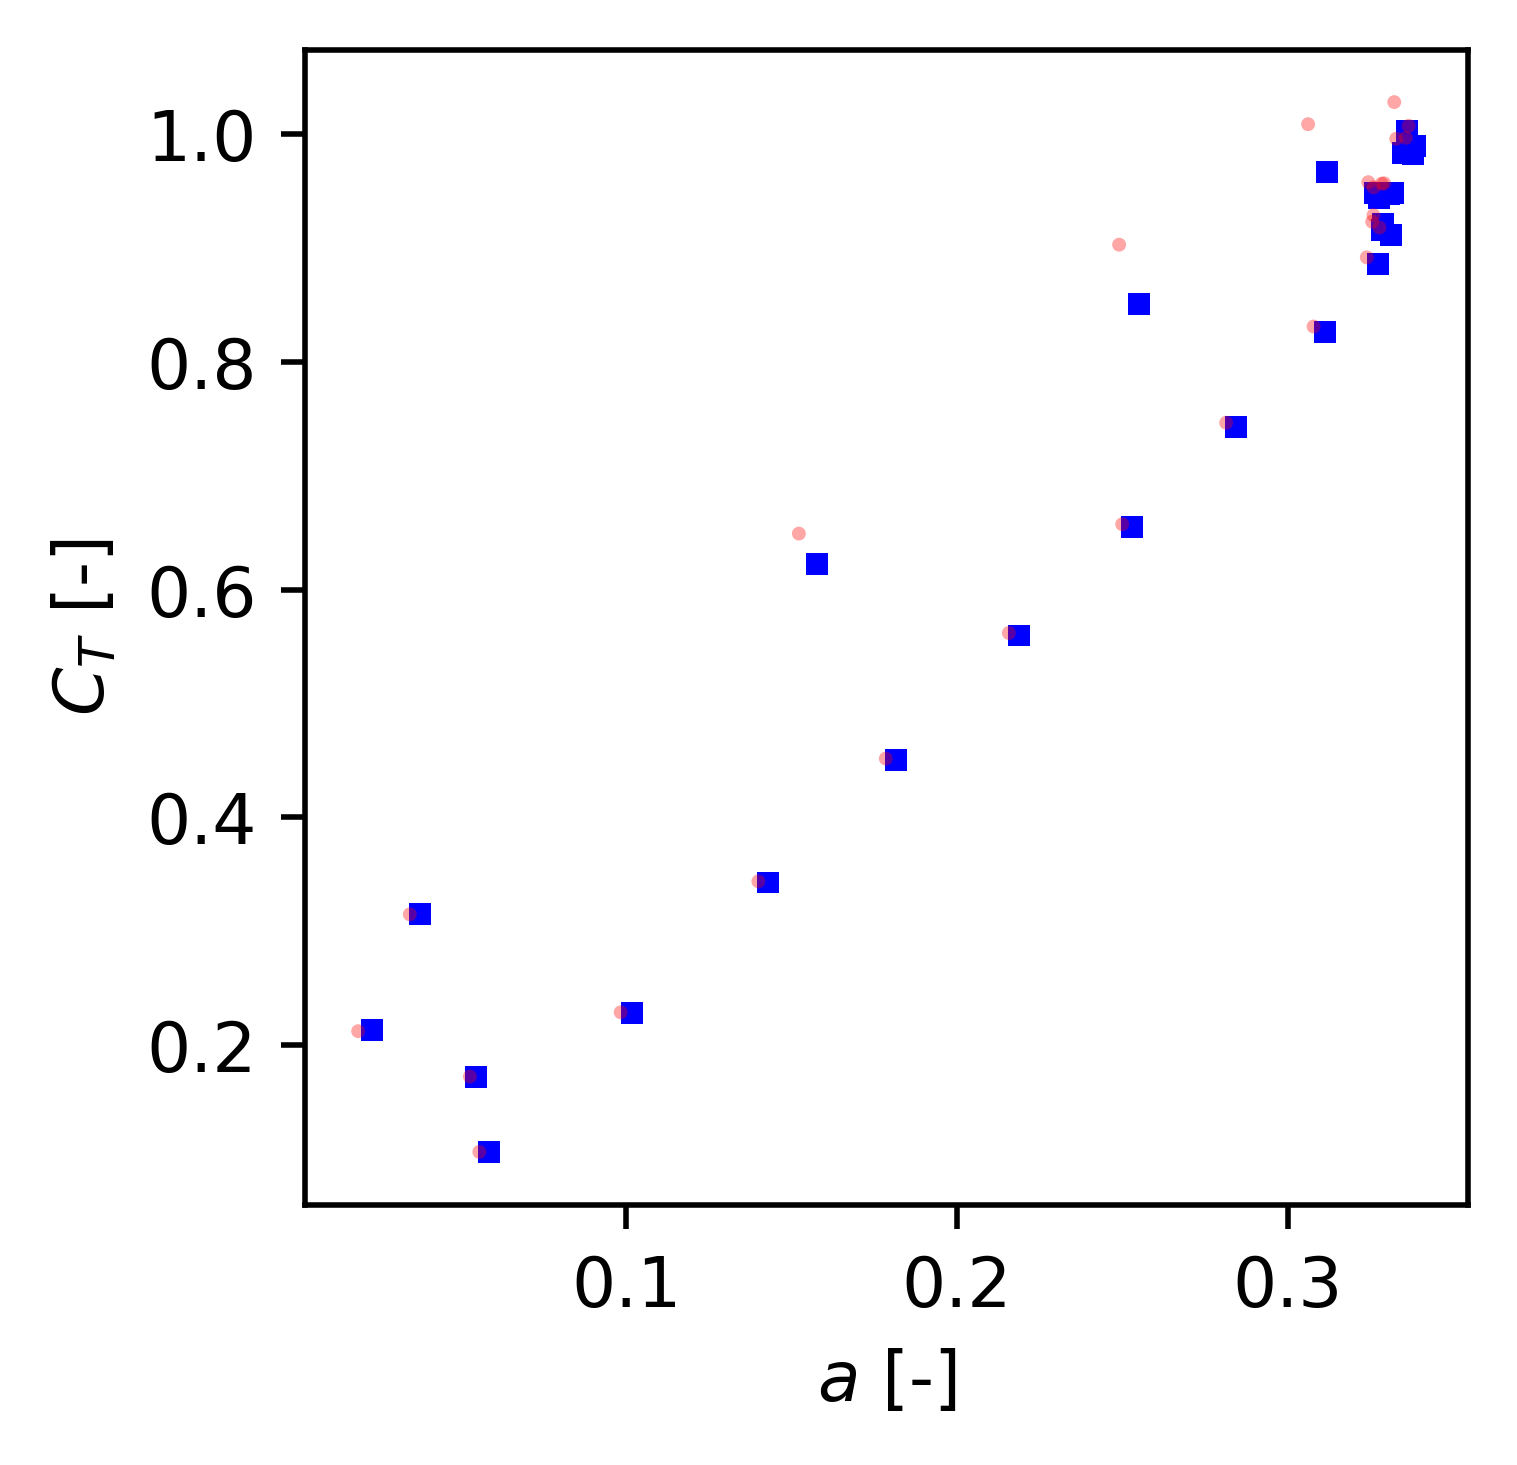

In [ ]:
a_mom = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)

# uniform = 31

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad

fig, ax = plt.subplots(figsize=(3, 3))

ax.scatter(y_rot[uniform], X_rot[uniform, 1], s=10, color='b', marker='s', label='Training data', edgecolor='none')
ax.scatter(gpa_ind_a[:,4],  gpa_cot_a[:,4], s=4, color='r', label = 'GP Prediction',alpha=0.35,edgecolor='none')

# ax.set_xlim([0.21,0.28])
# ax.set_ylim([0.65,0.725])

ax.set_ylabel('$C_T$ [-]')
ax.set_xlabel('$a$ [-]')

Text(0.5, 0, '$a$ [-]')

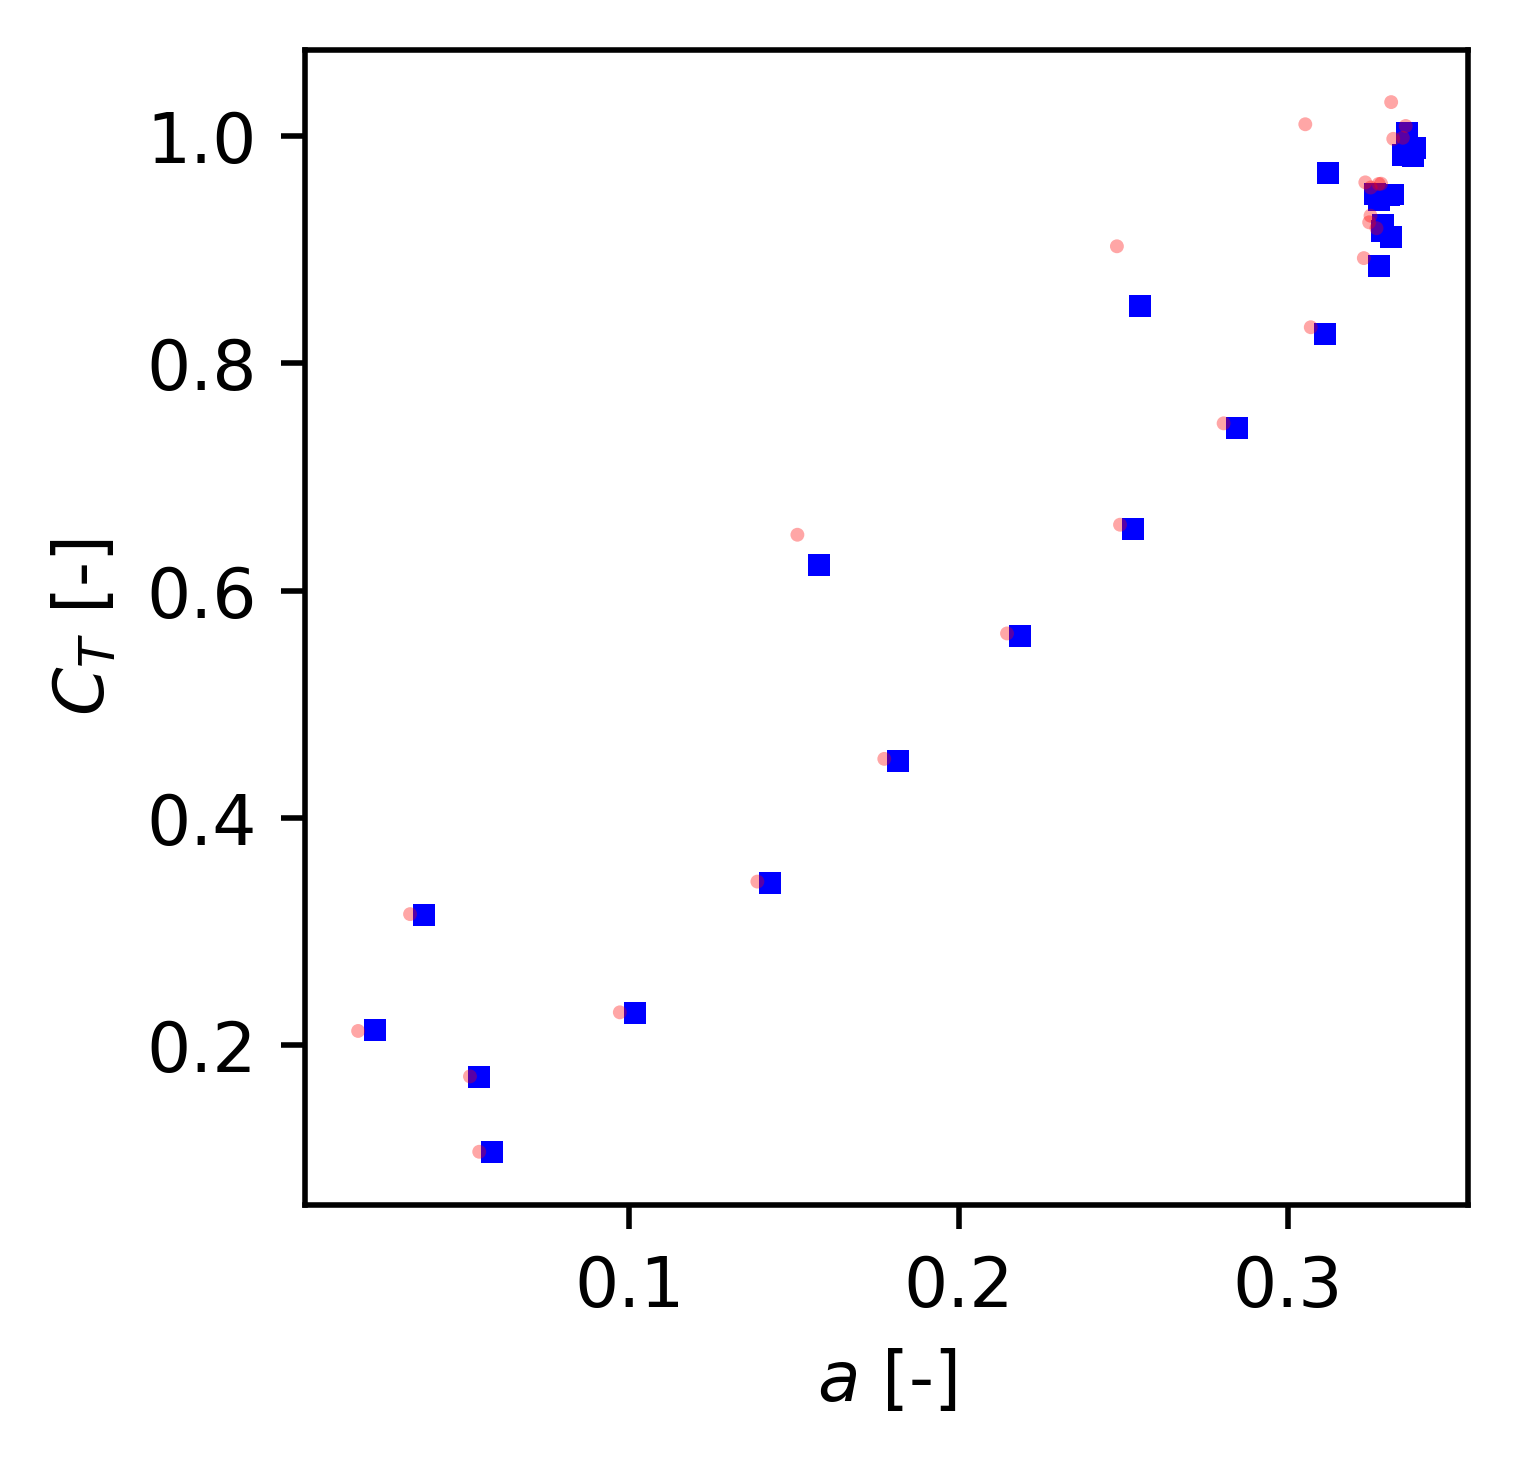

In [ ]:
a_mom = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)

# uniform = 31

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad

fig, ax = plt.subplots(figsize=(3, 3))

ax.scatter(y_rot[uniform], X_rot[uniform, 1], s=10, color='b', marker='s', label='Training data', edgecolor='none')
ax.scatter(gpa_ind_a[:,4],  gpa_cot_a[:,4], s=4, color='r', label = 'GP Prediction',alpha=0.35,edgecolor='none')

# ax.set_xlim([0.21,0.28])
# ax.set_ylim([0.65,0.725])

ax.set_ylabel('$C_T$ [-]')
ax.set_xlabel('$a$ [-]')

In [ ]:
len(uniform)

26